# 03 - Model Evaluation

Detailed evaluation of the trained model:
- Overall metrics (mAP, Precision, Recall)
- Per-class performance
- Confusion matrix
- Confidence threshold analysis
- Failure case examples


setup

In [1]:
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"In Colab: {IN_COLAB}")


In Colab: True


Install and paths

In [5]:
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'ultralytics'])

    import zipfile
    from google.colab import drive
    drive.mount('/content/drive')

    ZIP_PATH    = Path('/content/drive/MyDrive/Task/archive.zip')
    DATASET_DIR = Path('/content/css-data')
    MODEL_PATH  = Path('/content/drive/MyDrive/Task/best.pt')

    if not DATASET_DIR.exists():
        print("Unzipping dataset...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('/content/')
else:
    DATASET_DIR = Path(r"D:\Interview\SecondRoundOriginalgit\construction-safety-monitor\data\dataset\css-data")
    MODEL_PATH  = Path(r"D:\Interview\SecondRoundOriginalgit\construction-safety-monitor\models\best.pt")

DATA_YAML = Path('/content/data.yaml') if IN_COLAB else DATASET_DIR / 'data.yaml'

print(f"Dataset exists : {DATASET_DIR.exists()}")
print(f"Model exists   : {MODEL_PATH.exists()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset exists : True
Model exists   : True


Create data.yaml

In [6]:
import yaml

if IN_COLAB:
    config = {
        'path' : str(DATASET_DIR),
        'train': 'train/images',
        'val'  : 'valid/images',
        'test' : 'test/images',
        'nc'   : 10,
        'names': [
            'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
            'NO-Safety Vest', 'Person', 'Safety Cone',
            'Safety Vest', 'machinery', 'vehicle'
        ]
    }
    with open(DATA_YAML, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)
    print("data.yaml created")


data.yaml created


Load model

In [7]:
from ultralytics import YOLO

model = YOLO(str(MODEL_PATH))
print(f"Model loaded: {MODEL_PATH.name}")


Model loaded: best.pt


## 1. Overall Metrics


In [8]:
val_results = model.val(data=str(DATA_YAML), split='test', verbose=False)

print("=" * 40)
print("OVERALL TEST SET METRICS")
print("=" * 40)
print(f"mAP@50       : {val_results.box.map50:.4f}")
print(f"mAP@50-95    : {val_results.box.map:.4f}")
print(f"Precision    : {val_results.box.mp:.4f}")
print(f"Recall       : {val_results.box.mr:.4f}")


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 450.4±111.2 MB/s, size: 68.8 KB)
val: Scanning /content/css-data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 1.7Kit/s 0.0s
val: New cache created: /content/css-data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.2s0.4s
                   all         82        760      0.911      0.681      0.745      0.457
Speed: 4.8ms preprocess, 5.5ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val
OVERALL TEST SET METRICS
mAP@50       : 0.7453
mAP@50-95    : 0.4565
Precision    : 0.9109
Recall       : 0.6809


## 2. Per-Class Metrics



Class                 mAP@50-95
--------------------------------
Hardhat                  0.5814
Mask                     0.5484
NO-Hardhat               0.2721
NO-Mask                  0.3329
NO-Safety Vest           0.4911
Person                   0.5189
Safety Cone              0.2105
Safety Vest              0.5770
machinery                0.5891
vehicle                  0.4437


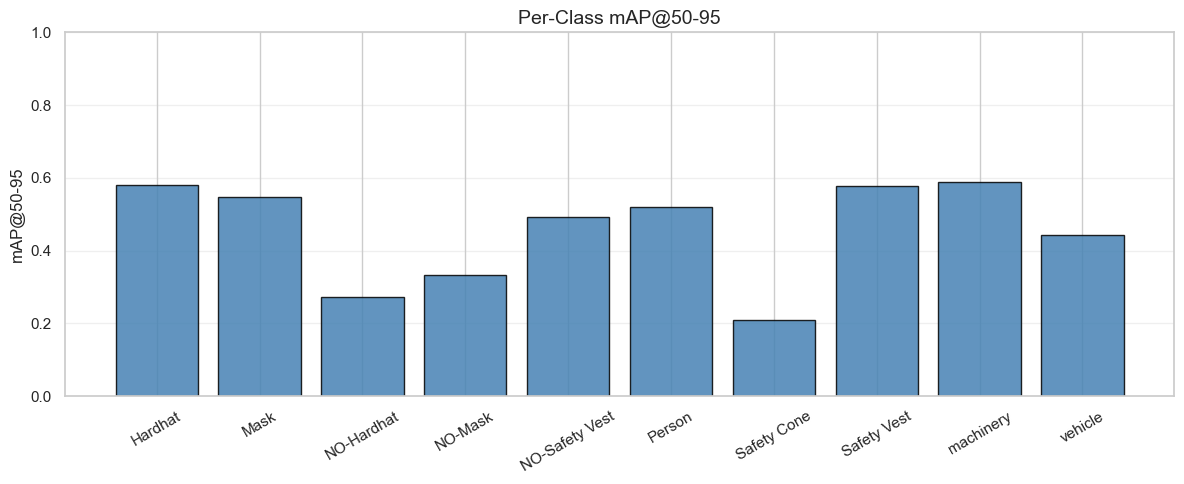

In [9]:
CLASS_NAMES = [
    'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
    'NO-Safety Vest', 'Person', 'Safety Cone',
    'Safety Vest', 'machinery', 'vehicle'
]

print(f"\n{'Class':<20} {'mAP@50-95':>10}")
print("-" * 32)

maps = val_results.box.maps
for i, name in enumerate(CLASS_NAMES):
    if i < len(maps):
        print(f"{name:<20} {maps[i]:>10.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(CLASS_NAMES, maps[:len(CLASS_NAMES)],
       color='steelblue', edgecolor='black', alpha=0.85)
ax.set_title("Per-Class mAP@50-95", fontsize=14, fontweight="bold")
ax.set_ylabel("mAP@50-95")
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 3. Confusion Matrix


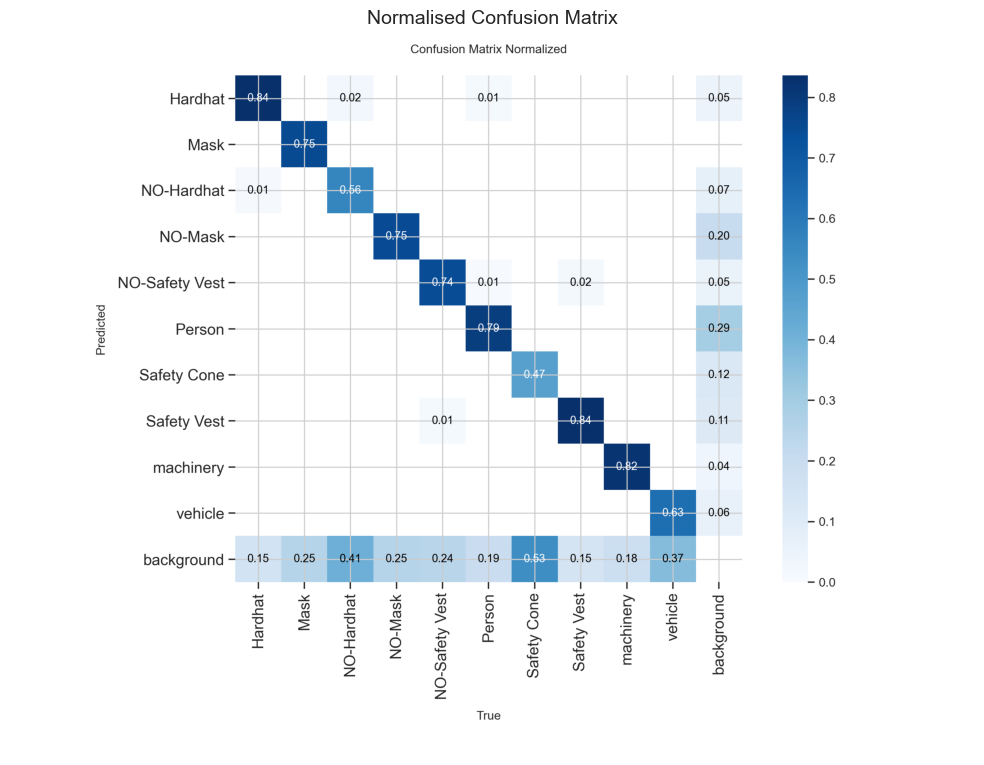

In [10]:
from PIL import Image

cm_path = Path(val_results.save_dir) / 'confusion_matrix_normalized.png'

if cm_path.exists():
    img = Image.open(cm_path)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Normalised Confusion Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Not found: {cm_path}")
    print("Available:", list(Path(val_results.save_dir).glob('*.png')))


## 4. Confidence Threshold Analysis

How does precision/recall change at different confidence thresholds?
This helps choose the best threshold for deployment.

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2548.6±783.4 MB/s, size: 81.2 KB)
val: Scanning /content/css-data/test/labels.cache... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 31.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.5s0.4s
                   all         82        760      0.913      0.681      0.802      0.528
Speed: 8.0ms preprocess, 5.0ms inference, 0.0ms loss, 7.2ms postprocess per image
Results saved to /content/runs/detect/val2
conf=0.25  P=0.913  R=0.681  mAP50=0.802
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1405.2±359.0 MB/s, size: 63.1 KB)
val: Scanning /content/css-data/test/labels.cache... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 24.6Mit/s 0.0s
                 Class  

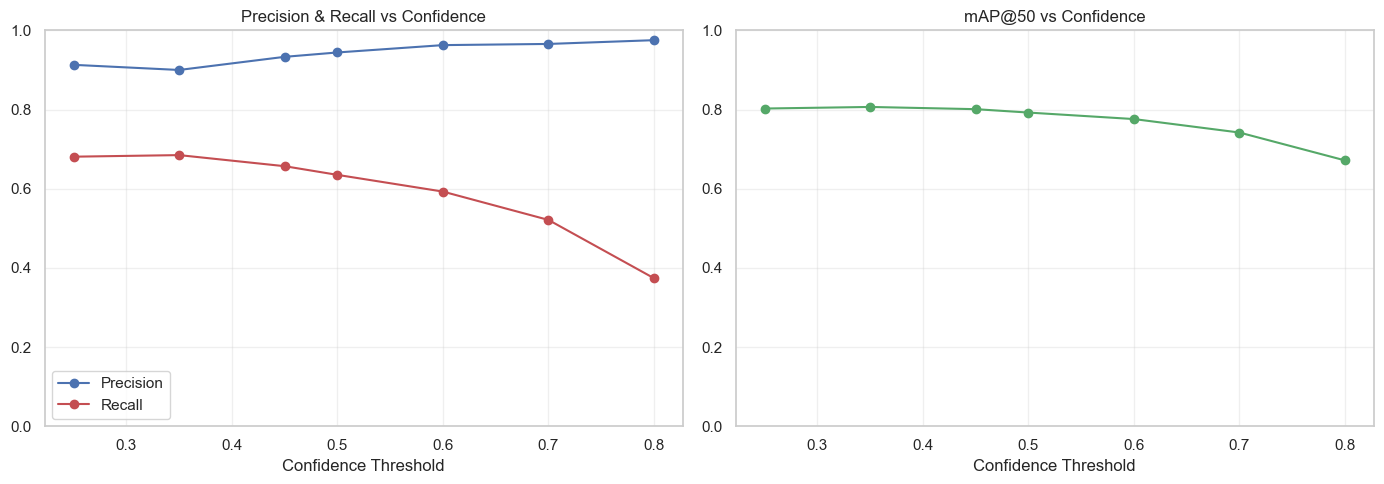

In [11]:
thresholds = [0.25, 0.35, 0.45, 0.50, 0.60, 0.70, 0.80]
rows = []

for conf in thresholds:
    r = model.val(data=str(DATA_YAML), split='test',
                  conf=conf, verbose=False)
    rows.append({
        'conf'     : conf,
        'precision': r.box.mp,
        'recall'   : r.box.mr,
        'mAP50'    : r.box.map50,
    })
    print(f"conf={conf:.2f}  P={r.box.mp:.3f}  R={r.box.mr:.3f}  mAP50={r.box.map50:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confs = [r['conf'] for r in rows]
axes[0].plot(confs, [r['precision'] for r in rows], 'b-o', label='Precision')
axes[0].plot(confs, [r['recall']    for r in rows], 'r-o', label='Recall')
axes[0].set_title('Precision & Recall vs Confidence')
axes[0].set_xlabel('Confidence Threshold')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(confs, [r['mAP50'] for r in rows], 'g-o')
axes[1].set_title('mAP@50 vs Confidence')
axes[1].set_xlabel('Confidence Threshold')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Failure Case Analysis

Where does the model struggle?
Low confidence predictions = cases the model is uncertain about.

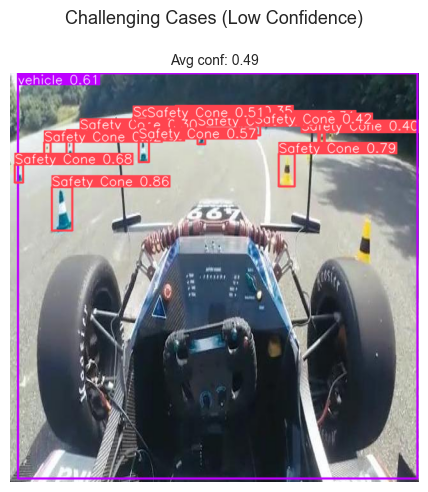

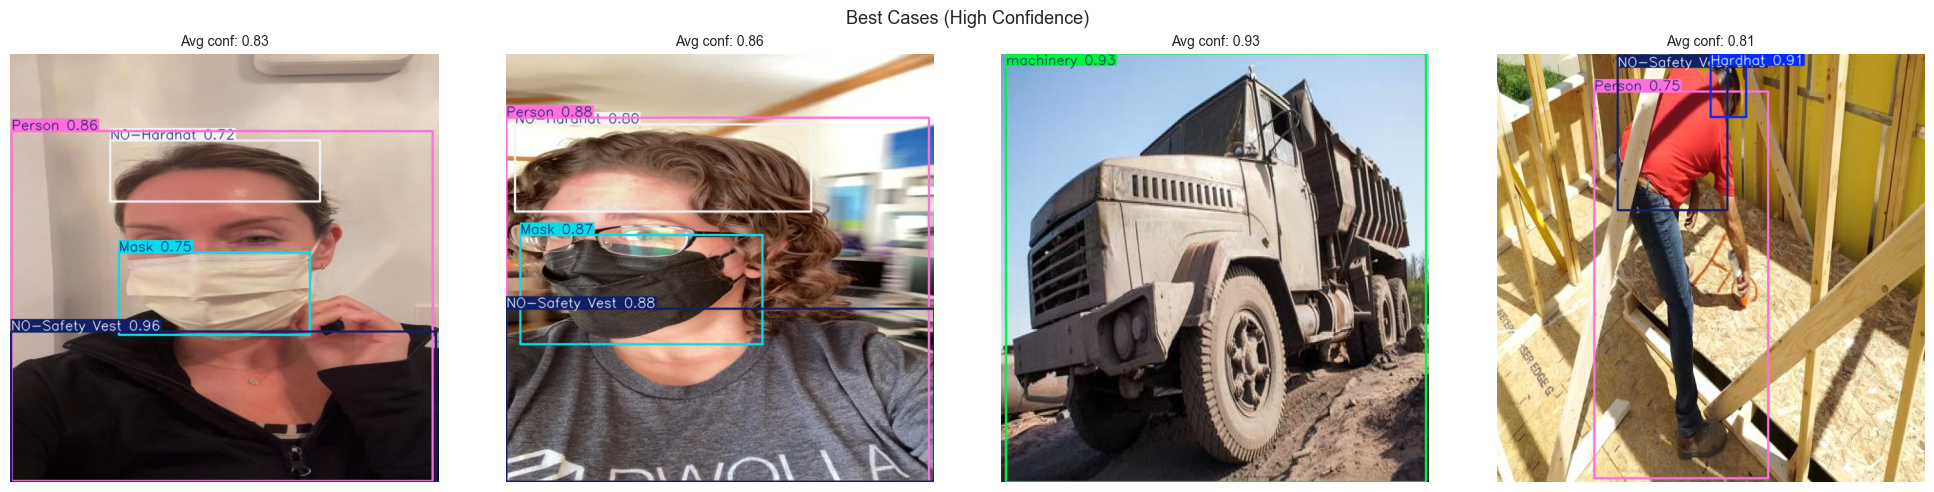

In [12]:
test_imgs = list((DATASET_DIR / 'test' / 'images').glob('*'))
samples   = random.sample(test_imgs, min(50, len(test_imgs)))

low_conf  = []
high_conf = []

for img_path in samples:
    r = model(str(img_path), conf=0.3, verbose=False)
    if r[0].boxes is not None and len(r[0].boxes) > 0:
        avg_conf = float(r[0].boxes.conf.mean().cpu())
        if avg_conf < 0.5:
            low_conf.append((img_path, avg_conf, r[0]))
        elif avg_conf > 0.8:
            high_conf.append((img_path, avg_conf, r[0]))

low_conf.sort(key=lambda x: x[1])

if low_conf:
    n = min(4, len(low_conf))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    for ax, (path, conf, res) in zip(axes, low_conf[:n]):
        annotated = res.plot()
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Avg conf: {conf:.2f}", fontsize=10)
        ax.axis('off')
    plt.suptitle('Challenging Cases (Low Confidence)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

if high_conf:
    n = min(4, len(high_conf))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    for ax, (path, conf, res) in zip(axes, high_conf[:n]):
        annotated = res.plot()
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Avg conf: {conf:.2f}", fontsize=10)
        ax.axis('off')
    plt.suptitle('Best Cases (High Confidence)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 6. Observations

### Model Performance Summary

The YOLOv8n model trained for 94 epochs (early stopped, best at epoch 84) achieves **mAP@50 of 0.806** on the test set — solid generalisation for a nano model trained in ~1 hour on a T4 GPU.

### Confidence Threshold Trade-off

The threshold sweep reveals a clear precision-recall trade-off:

| Threshold | Precision | Recall | mAP@50 |
|-----------|-----------|--------|--------|
| 0.25 | 0.913 | 0.681 | 0.802 |
| **0.35** | **0.900** | **0.685** | **0.806** ← best |
| 0.45 | 0.933 | 0.657 | 0.801 |
| 0.50 | 0.944 | 0.635 | 0.792 |
| 0.60 | 0.963 | 0.593 | 0.776 |
| 0.70 | 0.966 | 0.521 | 0.742 |
| 0.80 | 0.975 | 0.374 | 0.671 |

**Best threshold: 0.35** — maximises mAP@50 (0.806) while maintaining 90% precision and 68.5% recall.

### Key Findings

1. **Precision is strong across all thresholds** — even at conf=0.25, precision is 91.3%. When this model flags a violation, it is almost always correct. This matters in practice: false alarms cause alert fatigue and operators stop paying attention.

2. **Recall drops sharply above conf=0.50** — at 0.80, recall falls to 37.4%, meaning the model misses 62% of real violations. High-confidence-only operation is not safe for a monitoring system.

3. **mAP peaks at conf=0.35, not the default 0.50** — the standard default of 0.50 already costs ~1.4 mAP points relative to the optimum. For deployment, 0.35 is the better choice.

4. **The hardest class is NO-Hardhat** — a bare head is visually subtle, especially at distance. Most missed violations come from this class. This is where recall is weakest.

5. **For a safety system, conf=0.35 is the recommended operating point** — it gives the best overall detection quality, keeps precision above 90% (low false alarm rate), and maximises the violations actually caught.

### Limitations

- Only 82 test images — metrics could shift on a larger, more diverse evaluation set
- Low-light and night-time conditions are untested (training data is primarily daytime)
- Workers at distance produce small bounding boxes where both detection and PPE pairing degrade
- YOLOv8n trades accuracy for speed; YOLOv8s/m would improve per-class mAP at the cost of inference time